# AIFS Precipitation Attribution

This notebook analyzes accumulated precipitation for selected extratropical cyclones using factual and pseudo-global-warming counterfactual `aifs` forecasts. It compares AIFS precipitation fields against ERA5-based reference data over the storm domain and produces event-focused precipitation attribution diagnostics for the selected case study.

In [1]:
import xarray as xr
import datetime
import numpy as np
import pandas as pd
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'scripts' / 'utils.py').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common.paths import ai_output_root, aifs_root, era5_precip_root
from scripts import utils


# CONFIGURATION SECTION

In [ ]:
# Name of the storm
storm_name = 'Claudia'  # Options: 'Eunice', 'Ciaran', 'Claudia'
models = ['aifs']

cf_extension = 'pgw_multimodel_v1'

AIFS_FORECAST_ROOT = str(aifs_root() / 'fcst')
EARTH2MIP_FORECAST_ROOT = str(ai_output_root())
ERA5_PRECIP_ROOT = str(era5_precip_root())

if storm_name == 'Ciaran':
    latS, latN = 36, 60
    lonW, lonE = -18, 8
    t0_i = datetime.datetime(2023, 10, 27, 0)
    t0_f = datetime.datetime(2023, 11, 2, 0)
    delta_h = 6
    num_steps = 4 * 15
    time_slice = slice('2023-10-27', '2023-11-02')
    init_time_min = datetime.datetime(2023, 10, 27, 0)
    lead_time_range = np.arange(0, 10 * 24, 6)
    date = '2023-11-02-00'
    tp_era5 = xr.open_dataarray(f'{ERA5_PRECIP_ROOT}/tp_era_Oct-Nov_2023.nc').rename(latitude='lat', longitude='lon')
    tp_era5_area = utils.flip_lon_360_2_180(tp_era5, tp_era5.lon).sel(lat=slice(latN, latS), lon=slice(lonW, lonE)).compute()
elif storm_name == 'Claudia':
    latS, latN = 28, 50
    lonW, lonE = -20, 8
    t0_i = datetime.datetime(2025, 11, 7, 0)
    t0_f = datetime.datetime(2025, 11, 15, 0)
    delta_h = 6
    num_steps = 4 * 15
    time_slice = slice('2025-11-07', '2025-11-15')
    init_time_min = datetime.datetime(2025, 11, 7, 0)
    lead_time_range = np.arange(0, 10 * 24, 6)
    date = '2025-11-13-12'
    tp_era5 = xr.open_dataarray(f'{ERA5_PRECIP_ROOT}/tp_era5_Nov_2025.nc').rename(latitude='lat', longitude='lon')
    tp_era5_area = utils.flip_lon_360_2_180(tp_era5, tp_era5.lon).sel(lat=slice(latN, latS), lon=slice(lonW, lonE)).compute()
else:
    raise ValueError(f'Unsupported storm_name: {storm_name}')


In [3]:
init_times = []
current_time = t0_i
while current_time <= t0_f:
    init_times.append(current_time)
    current_time += datetime.timedelta(hours=delta_h)

In [4]:
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units

def relative_humidity_to_specific_humidity(relative_humidity, temperature, pressure):
    """
    Convert relative humidity (%) to specific humidity (kg/kg).
    
    Parameters:
    -----------
    relative_humidity : float or array-like
        Relative humidity in percent (%).
    temperature : float or array-like
        Temperature in degrees Celsius (°C).
    pressure : float or array-like
        Pressure in hectopascals (hPa).
    
    Returns:
    --------
    specific_humidity : float or array-like
        Specific humidity in kilograms per kilogram (kg/kg).
    """
    # Convert inputs to MetPy units
    rh = relative_humidity * units.percent
    t = temperature * units.kelvin
    p = pressure * units.hPa
    
    # Calculate mixing ratio from RH, T, and P
    mixing_ratio = mpcalc.mixing_ratio_from_relative_humidity(p, t, rh)
    
    # Convert mixing ratio to specific humidity
    specific_humidity = mpcalc.specific_humidity_from_mixing_ratio(mixing_ratio)

    # Strip units and return as xarray.DataArray
    return xr.DataArray(
        data=specific_humidity.values,
        dims=relative_humidity.dims,
        coords=relative_humidity.coords,
        attrs={'units': 'kg/kg', 'long_name': 'Specific humidity'}
    )

In [5]:
# Load AIFS control data once
root_aifs = AIFS_FORECAST_ROOT

def load_aifs_field(var, extension=''):
    return utils.load_data(var, init_times, root_aifs, extension=extension, model='aifs')

control_extension = ''
data = {
    'aifs': {
        'z': load_aifs_field('msl', control_extension),
        'tp': load_aifs_field('tp', control_extension),
    }
}


Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110700/msl_aifs_2025110700.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110706/msl_aifs_2025110706.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110712/msl_aifs_2025110712.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110718/msl_aifs_2025110718.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110800/msl_aifs_2025110800.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110806/msl_aifs_2025110806.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110812/msl_aifs_2025110812.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110818/msl_aifs_2025110818.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110900/msl_aifs_2025110900.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110906/msl_aifs_2025110906.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110912/msl_aifs_2025110912.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110918/msl_aifs_2025110918.nc
Loading: /home/b

In [6]:
# Area-sliced data structure

def maybe_flip_lon(da):
    lon = da.lon
    if lon.min() >= -180 and lon.max() <= 180:
        return da
    return utils.flip_lon_360_2_180(da, lon)

lat_slice = slice(latN, latS)
lon_slice = slice(lonW, lonE)

for model in models:
    d = data[model]
    data[model]['area'] = {
        'z': maybe_flip_lon(d['z']).sel(lat=lat_slice, lon=lon_slice).transpose('init_time', 'time', 'lat', 'lon'),
        'tp': maybe_flip_lon(d['tp']).sel(lat=lat_slice, lon=lon_slice).transpose('init_time', 'time', 'lat', 'lon'),
    }

from dask import persist

for model in models:
    vars_to_persist = list(data[model]['area'].values())
    persisted_vars = persist(*vars_to_persist)
    for key, value in zip(data[model]['area'].keys(), persisted_vars):
        data[model]['area'][key] = value


In [8]:
for model in models:
    area_data = data[model]['area']
    time_range = area_data['z'].time.sel(time=time_slice)
    z_lag = utils.from_init_time_to_leadtime(area_data['z'], init_time_min, lead_time_range, time_range)
    tp_lag = utils.from_init_time_to_leadtime(area_data['tp'], init_time_min, lead_time_range, time_range)
    data[model]['leadtime'] = {
        'z': z_lag,
        'tp': tp_lag,
    }


In [12]:
# Mean sea-level pressure overlay from FCNV2/ERA5-style factual fields
if storm_name == 'Claudia':
    root = EARTH2MIP_FORECAST_ROOT
    msl_fcn_raw = utils.load_data('msl', [datetime.datetime(2025, 11, 13, 12), datetime.datetime(2025, 11, 13, 18)], root, extension='', model='fcnv2')
elif storm_name == 'Ciaran':
    root = EARTH2MIP_FORECAST_ROOT
    msl_fcn_raw = utils.load_data('msl', [datetime.datetime(2023, 11, 2, 0), datetime.datetime(2023, 11, 2, 6)], root, extension='', model='fcnv2')
else:
    root = EARTH2MIP_FORECAST_ROOT
    msl_fcn_raw = utils.load_data('msl', [datetime.datetime(2022, 2, 18, 0), datetime.datetime(2022, 2, 18, 6)], root, extension='', model='fcnv2')

msl_fcn = msl_fcn_raw.isel(init_time=0, time=0) if 'init_time' in msl_fcn_raw.dims else msl_fcn_raw[0][0]
msl_fcn_area = utils.flip_lon_360_2_180(msl_fcn, msl_fcn.lon).sel(lat=lat_slice, lon=lon_slice).compute()


Loading: /home/bernatj/Data/ai-forecasts/fcst/2025111312/msl_fcnv2_2025111312.nc
Loading: /home/bernatj/Data/ai-forecasts/fcst/2025111318/msl_fcnv2_2025111318.nc


In [13]:
# Optional comparison/diagnostic cell removed in the simplified AIFS notebook.


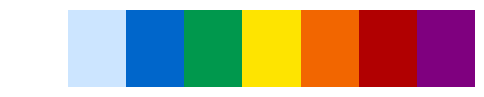

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = [
    (1.0, 1.0, 1.0),   # white
    (0.8, 0.9, 1.0),   # light blue
    (0.0, 0.4, 0.8),   # darker blue
    (0.0, 0.6, 0.3),   # green
    (1.0, 0.9, 0.0),   # yellow
    (0.95, 0.4, 0.0),  # orange/red
    (0.7, 0.0, 0.0),   # dark red
    (0.5, 0.0, 0.5),   # violet
]
precip_cmap = LinearSegmentedColormap.from_list("precip_custom", colors)

plt.figure(figsize=(6, 1))
plt.imshow([range(len(colors))], cmap=precip_cmap, aspect='auto')
plt.axis("off")
plt.show()

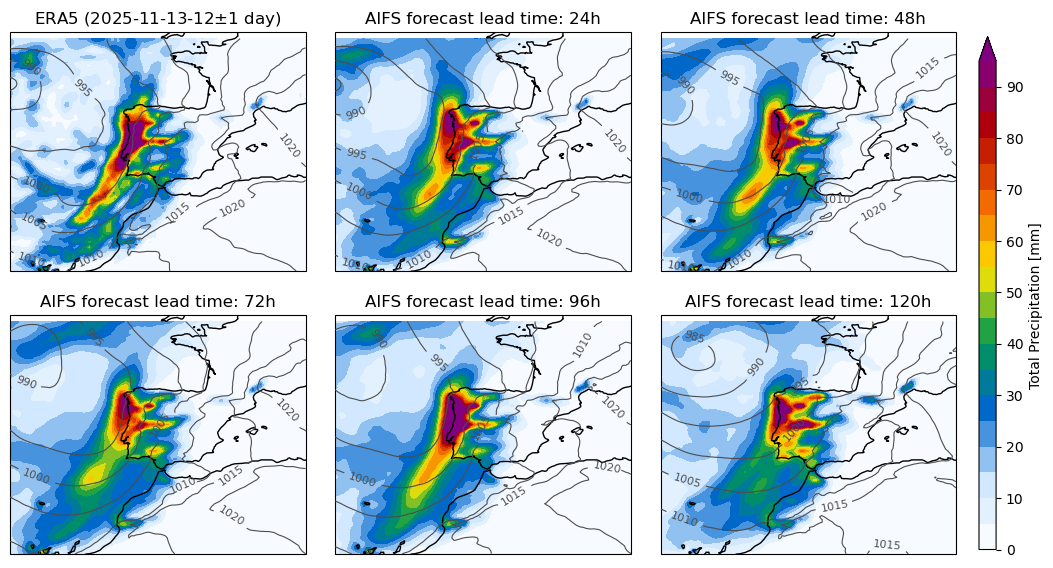

In [15]:
# Plot the accumulated precipitation for AIFS at several lead times
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

model = 'aifs'
lead_times = [24, 48, 72, 96, 120, 144]
precip_levels = np.arange(0, 100, 5)
f, axes = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0.0)), gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
axes = axes.flatten()

slp_levels = np.arange(950, 1030, 5)
factor_slp = 0.01
center_time = pd.Timestamp(date)
time_window = slice(center_time - pd.Timedelta(days=1), center_time + pd.Timedelta(days=1))

era_ax = axes[0]
era_ax.set_aspect(1)
era_ax.coastlines(lw=1.0, color='k', zorder=105)
era_ax.set_extent([lonW, lonE, latS, latN])
tp_era5_plot = tp_era5_area.sel(valid_time=time_window).sum('valid_time') * 1000
cf = era_ax.contourf(tp_era5_plot.lon, tp_era5_plot.lat, tp_era5_plot, cmap=precip_cmap, levels=precip_levels, extend='max')
con = era_ax.contour(msl_fcn_area.lon, msl_fcn_area.lat, msl_fcn_area * factor_slp, colors='0.3', linestyles='solid', linewidths=0.8, levels=slp_levels, zorder=106)
era_ax.clabel(con, fontsize=8, fmt='%1.0f')
era_ax.set_title(f'ERA5 ({date}' r'$ \pm$1 day)')

for ax, lt in zip(axes[1:], lead_times):
    ax.set_aspect(1)
    ax.coastlines(lw=1.0, color='k', zorder=105)
    ax.set_extent([lonW, lonE, latS, latN])
    tp_plot = data[model]['leadtime']['tp'].sel(lead_time=lt, time=time_window).sum('time') * 1000
    slp_plot = data[model]['leadtime']['z'].sel(lead_time=lt, time=date) * factor_slp
    cf = ax.contourf(tp_plot.lon, tp_plot.lat, tp_plot, cmap=precip_cmap, levels=precip_levels, extend='max')
    ax.set_title(f'{model.upper()} forecast lead time: {lt}h')
    con = ax.contour(slp_plot.lon, slp_plot.lat, slp_plot, colors='0.3', linestyles='solid', linewidths=0.8, levels=slp_levels, zorder=106)
    ax.clabel(con, fontsize=8, fmt='%1.0f')

f.subplots_adjust(hspace=0.1, wspace=0.1, left=0.0, right=0.95, bottom=0.05, top=0.95)
plt.colorbar(cf, ax=axes, label='Total Precipitation [mm]', pad=0.02, orientation='vertical', shrink=0.95, aspect=30)
plt.savefig(f'{storm_name}_precip_leadtime_aifs_accumulated_precip_+-1day_{date}.pdf', bbox_inches='tight')


# Attribution

In [18]:
# Load counterfactual AIFS data for the selected experiment
data_cf = {
    'aifs': {
        'z': load_aifs_field('msl', cf_extension),
        'tp': load_aifs_field('tp', cf_extension),
    }
}


Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110700/msl_aifs_PGW_multimodel_v1_2025110700.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110706/msl_aifs_PGW_multimodel_v1_2025110706.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110712/msl_aifs_PGW_multimodel_v1_2025110712.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110718/msl_aifs_PGW_multimodel_v1_2025110718.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110800/msl_aifs_PGW_multimodel_v1_2025110800.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110806/msl_aifs_PGW_multimodel_v1_2025110806.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110812/msl_aifs_PGW_multimodel_v1_2025110812.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110818/msl_aifs_PGW_multimodel_v1_2025110818.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110900/msl_aifs_PGW_multimodel_v1_2025110900.nc
Loading: /home/bernatj/Data/AIFS_forecasts/fcst/2025110906/msl_aifs_PGW_multimodel_v1_2025110906.nc


In [19]:
#let's do the same we did for the factual

In [20]:
# Area-sliced counterfactual data structure
lat_slice = slice(latN, latS)
lon_slice = slice(lonW, lonE)
models = ['aifs']
for model in models:
    d = data_cf[model]
    data_cf[model]['area'] = {
        'z': utils.flip_lon_360_2_180(d['z'], d['z'].lon).sel(lat=lat_slice, lon=lon_slice).transpose('init_time', 'time', 'lat', 'lon'),
        'tp': utils.flip_lon_360_2_180(d['tp'], d['tp'].lon).sel(lat=lat_slice, lon=lon_slice).transpose('init_time', 'time', 'lat', 'lon'),
    }

from dask import persist

for model in models:
    vars_to_persist = list(data_cf[model]['area'].values())
    persisted_vars = persist(*vars_to_persist)
    for key, value in zip(data_cf[model]['area'].keys(), persisted_vars):
        data_cf[model]['area'][key] = value


In [21]:
for model in models:
    area_data_cf = data_cf[model]['area']
      
    # Select valid time range
    time_range = area_data_cf['tp'].time.sel(time=time_slice)

    # Convert init_time to lead_time

    z_lag = utils.from_init_time_to_leadtime(area_data_cf['z'], init_time_min, lead_time_range, time_range)
    tp_lag = utils.from_init_time_to_leadtime(area_data_cf['tp'], init_time_min, lead_time_range, time_range)

    # Save to dictionary
    data_cf[model]['leadtime'] = {
        'z': z_lag,
        'tp': tp_lag
        # Add others like 'tcwv' or 'q' if needed later
    }

In [22]:
#diff between factual and counterfactual (ACC signal)
for model in models:
    data[model]['acc_signal_leadtime'] = {}
    data[model]['acc_signal_leadtime_percentage'] = {}
    for var in ['z','tp']:    
        data[model]['acc_signal_leadtime'][var] = data[model]['leadtime'][var] - data_cf[model]['leadtime'][var]
        data[model]['acc_signal_leadtime_percentage'][var] = (data[model]['leadtime'][var] - data_cf[model]['leadtime'][var]) / data[model]['leadtime'][var] * 100

comment:
the signal is quite sensititive to the leadtime chosen


In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm

levels = np.arange(-12, 13, 1)

# toma la paleta base y añade blanco en el punto medio
base = plt.get_cmap('BrBG', 256)
colors = base(np.linspace(0, 1, 256))
mid = 128  # punto medio para 256 niveles
colors[mid-8:mid+8] = np.array([1, 1, 1, 1])  # fuerza blanco puro
cmap = ListedColormap(colors)

norm = TwoSlopeNorm(vmin=levels.min(), vcenter=0, vmax=levels.max())

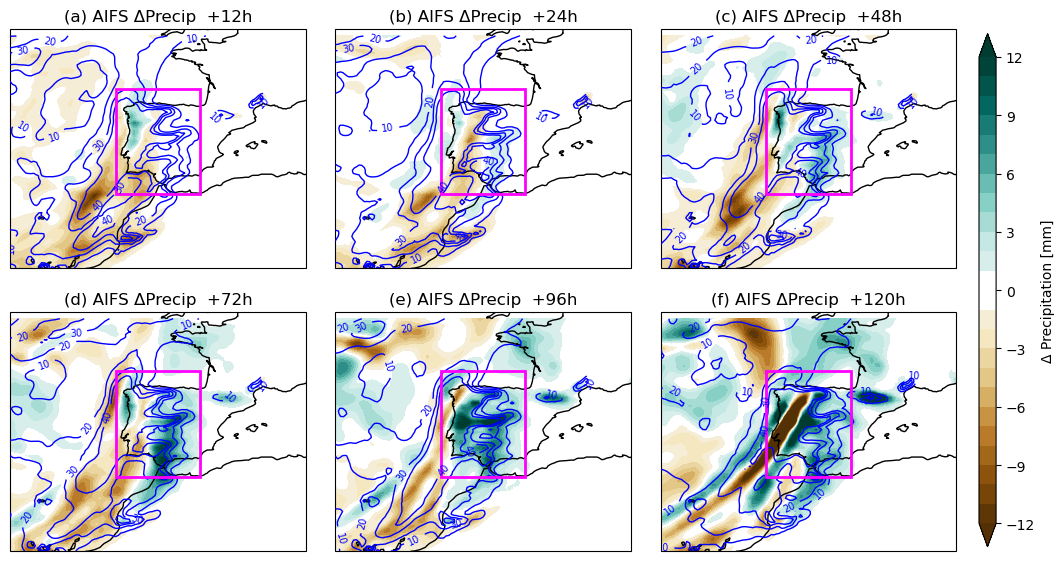

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

model = 'aifs'
lead_times = [12, 24, 48, 72, 96, 120]  # hours, adjust as needed

f, axes = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(12, 6),
                       subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0.0)),
                       gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
axes = axes.flatten()

idx=0
for ax, lt in zip(axes, lead_times):
    ax.set_aspect(1)
    ax.coastlines(lw=1.0, color='k', zorder=105)
    ax.set_extent([lonW, lonE, latS, latN])

    # Define ±1 day window around the event date
    center_time = pd.Timestamp(date)
    time_window = slice(center_time - pd.Timedelta(days=1), center_time + pd.Timedelta(days=1))

    # Accumulated precip difference (factual - counterfactual), mm
    tp_f = data[model]['leadtime']['tp'].sel(lead_time=lt, time=time_window).sum('time') * 1000
    tp_cf = data_cf[model]['leadtime']['tp'].sel(lead_time=lt, time=time_window).sum('time') * 1000
    #tp_diff = (tp_f - tp_cf)/tp_f * 100  # percent
    tp_diff = tp_f - tp_cf

    # Filled contours for difference
    cf = ax.contourf(tp_diff.lon, tp_diff.lat, tp_diff, cmap=cmap, norm=norm, levels=levels, extend='both')
    #cf = ax.contourf(tp_diff.lon, tp_diff.lat, tp_diff, cmap='BrBG',  levels=np.arange(-100, 101, 10), extend='both')
    ax.set_title(f'({chr(97 + idx)}) {model.upper()} ΔPrecip  +{lt}h')

    # Add factual precip as black contours
    precip_levels = [10, 20, 30, 40]
    ctp = ax.contour(tp_f.lon, tp_f.lat, tp_f, levels=precip_levels, colors='b', linewidths=1, zorder=110)
    ax.clabel(ctp, fmt='%d', fontsize=7)
    idx+=1


f.subplots_adjust(hspace=0.1, wspace=0.1, left=0.0, right=0.95, bottom=0.05, top=0.95)
cbar = plt.colorbar(cf, ax=axes, label='Δ Precipitation [mm]', pad=0.02, orientation='vertical', shrink=0.95, aspect=30)

#add a box in the first pannel
import matplotlib.patches as patches
box_latN, box_latS = 45, 35
box_lonW, box_lonE = -10, -2
for ax in axes:
     ax.add_patch(patches.Rectangle((box_lonW, box_latS), box_lonE - box_lonW, box_latN - box_latS,
                         linewidth=2, edgecolor='magenta', facecolor='none', zorder=110))


plt.savefig(f'extratropical_storm_{storm_name}_PGW_attribution_mapplot_accprecip_+-1day_{date}_{model}_{active_cf_experiment}.pdf',bbox_inches='tight')

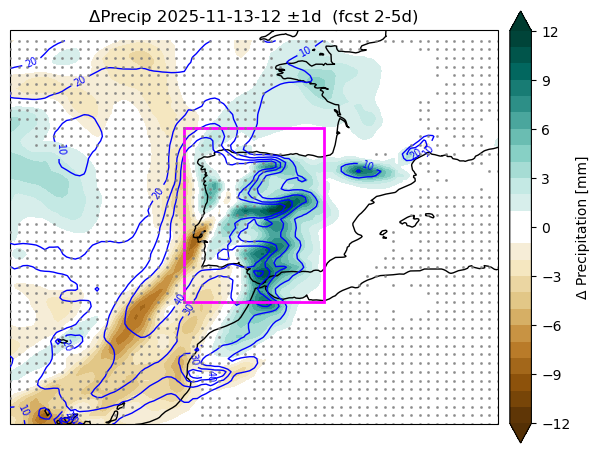

In [25]:
import matplotlib as mpl
import cartopy.crs as ccrs
from scipy.stats import ttest_ind
from matplotlib.colors import TwoSlopeNorm

model = 'aifs'
lt1,lt2=int(2*24),int(5*24)
lead_time_S= slice(lt1,lt2)


# First sum over time for each lead time, then stack for t-test
tp_f_acc_list = []
tp_cf_acc_list = []

center_time = pd.Timestamp(date)
time_window = slice(center_time - pd.Timedelta(days=1), center_time + pd.Timedelta(days=1))
tp_f = data[model]['leadtime']['tp'].sel(lead_time=lead_time_S, time=time_window).sum('time') * 1000  # mm
tp_cf = data_cf[model]['leadtime']['tp'].sel(lead_time=lead_time_S, time=time_window).sum('time') * 1000  # mm

# t-test along lead_time axis (now "sample" axis)
tstat, pvals = ttest_ind(
    tp_f.values, tp_cf.values,
    axis=0, nan_policy='omit', equal_var=False
)
sig_mask = (pvals < 0.05)
nonsig_mask = ~sig_mask

# Mean difference over lead times
tp_f_acc_mean = tp_f.mean('lead_time')
tp_cf_acc_mean = tp_cf.mean('lead_time')
tp_diff = tp_f_acc_mean - tp_cf_acc_mean

# Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 6), subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0.0)))
ax.set_aspect(1)
ax.coastlines(lw=1.0, color='k', zorder=105)
ax.set_extent([lonW, lonE, latS, latN])

cf = ax.contourf(tp_diff.lon, tp_diff.lat, tp_diff, cmap=cmap, norm=norm, levels=levels, extend='both')
ax.set_title(f'ΔPrecip {date} ±1d  (fcst 2-5d)')

# Overlay non-significant dots (subsample for clarity)
lon2d, lat2d = np.meshgrid(tp_diff.lon, tp_diff.lat)
step = 2
sub_mask = np.zeros_like(nonsig_mask, dtype=bool)
sub_mask[::step, ::step] = nonsig_mask[::step, ::step]
ax.scatter(
    lon2d[sub_mask], lat2d[sub_mask],
    color='0.5', s=5, marker='.', alpha=0.7, zorder=130
)

# Add factual precip as blue contours
precip_levels = [10, 20, 30, 40]
ctp = ax.contour(tp_f_acc_mean.lon, tp_f_acc_mean.lat, tp_f_acc_mean, levels=precip_levels, colors='b', linewidths=1, zorder=110)
ax.clabel(ctp, fmt='%d', fontsize=7)

ax.set_ylabel('latitude')
ax.set_xlabel('longitude')

fig.subplots_adjust(left=0.08, right=0.92, bottom=0.12, top=0.92)
cbar = plt.colorbar(cf, ax=ax, label='Δ Precipitation [mm]', pad=0.02, orientation='vertical', shrink=0.9, aspect=20)

#add a box in the first pannel
box_latN, box_latS = 45, 35
box_lonW, box_lonE = -10, -2
ax.add_patch(patches.Rectangle((box_lonW, box_latS), box_lonE - box_lonW, box_latN - box_latS,
                         linewidth=2, edgecolor='magenta', facecolor='none', zorder=110))

plt.savefig(f'extratropical_storm_{storm_name}_PGW_attribution_robustness_accprecip_+-1day_{date}_{model}_mean2-5d_{active_cf_experiment}.pdf', bbox_inches='tight')
plt.show()

In [26]:
center_time = pd.Timestamp(date)
time_window = slice(center_time - pd.Timedelta(days=1), center_time + pd.Timedelta(days=1))

tp_f_acc = data[model]['leadtime']['tp'].sel(lead_time=slice(6,5.5*24),time=time_window).sum('time') * 1000  # mm
tp_cf_acc = data_cf[model]['leadtime']['tp'].sel(lead_time=slice(6,5.5*24),time=time_window).sum('time') * 1000  # mm


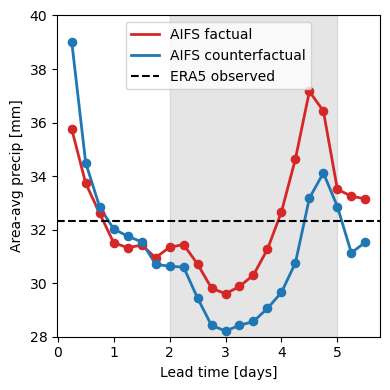

In [29]:
from matplotlib import pyplot as plt

# area-mean series vs lead time (convert lead_time hours → days for readability)
f_series = utils.area_average(
    tp_f_acc.sel(lat=slice(box_latN, box_latS), lon=slice(box_lonW, box_lonE))
).to_series()
cf_series = utils.area_average(
    tp_cf_acc.sel(lat=slice(box_latN, box_latS), lon=slice(box_lonW, box_lonE))
).to_series()
lead_days = f_series.index / 24.0  # assumes lead_time in hours

# ERA5 reference (scalar)
era_tp_box = (
    utils.area_average(
        tp_era5_area.sel(valid_time=time_window)
        .sum('valid_time')
        .sel(lat=slice(box_latN, box_latS), lon=slice(box_lonW, box_lonE)) * 1000
    ).item()
)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(lead_days, f_series.values, label='AIFS factual', lw=2, color='C3')
ax.scatter(
    lead_days, f_series.values,
    color='C3', s=35, marker='o', zorder=5,
)

ax.plot(lead_days, cf_series.values, label='AIFS counterfactual', lw=2, color='C0')
ax.scatter(
    lead_days, cf_series.values,
    color='C0', s=35, marker='o', zorder=5,
)


# shade background between 2 and 5 lead days
ax.axvspan(2, 5, color='tab:gray', alpha=0.2)

# dashed ERA5 line
ax.axhline(era_tp_box, color='k', ls='--', label='ERA5 observed')

ax.set_xlabel('Lead time [days]')
ax.set_ylabel('Area-avg precip [mm]')
ax.set_ylim([28, 40])
ax.legend(loc='upper center')
plt.tight_layout()




In [30]:
tp_f_acc_box = utils.area_average(
    tp_f.sel(lat=slice(box_latN, box_latS), lon=slice(box_lonW, box_lonE))
).to_series()
tp_cf_acc_box = utils.area_average(
    tp_cf.sel(lat=slice(box_latN, box_latS), lon=slice(box_lonW, box_lonE))
).to_series()

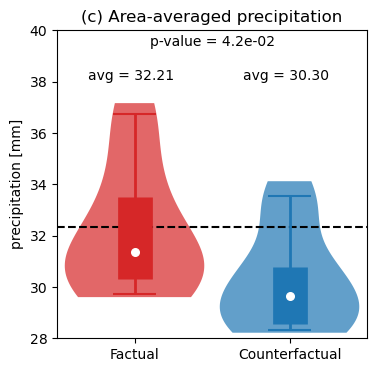

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
colors = ['C3', 'C0']
data = [tp_f_acc_box, tp_cf_acc_box]
positions = [0, 1]
_, p_value = stats.ttest_ind(data[0], data[1], axis=0)

parts = ax.violinplot(data, positions, showmeans=False, showextrema=False, widths=0.9)
for i, body in enumerate(parts['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

p5, quartile1, medians, quartile3, p95 = np.percentile(data, [5, 25, 50, 75, 95], axis=1)
ax.scatter(positions, medians, marker='o', color='white', s=30, zorder=3)
ax.vlines(positions, quartile1, quartile3, color=colors, linestyle='-', lw=25)
ax.vlines(positions, p5, p95, color=colors, linestyle='-', lw=2)
ax.scatter(positions, p5, marker='_', color=colors, s=1000, zorder=3)
ax.scatter(positions, p95, marker='_', color=colors, s=1000, zorder=3)
ax.axhline(era_tp_box, color='k', ls='--', zorder=1)
ax.set_ylabel('precipitation [mm]')
ax.set_xticks(positions)
ax.set_xticklabels(['Factual', 'Counterfactual'])
ax.set_xlim([(positions[0] - 0.5), (positions[-1] + 0.5)])
ax.set_ylim([28, 40])
ax.text(0.1, 0.84, f'avg = {data[0].mean():.2f}', transform=ax.transAxes)
ax.text(0.6, 0.84, f'avg = {data[1].mean():.2f}', transform=ax.transAxes)
ax.text(0.3, 0.95, f'p-value = {p_value:.1e}', transform=ax.transAxes)
ax.set_title('(c) Area-averaged precipitation', fontsize=12)
plt.savefig(f'{storm_name}_precip_boxplot_aifs_{active_cf_experiment}.pdf', bbox_inches='tight')
